In [25]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.stats import norm
import numpy as np 


C:\Users\fzmaj\AppData\Local\Temp\ipykernel_21184\117745822.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  DSet['CheckInHour'] = pd.to_datetime(DSet['CheckInTime']).dt.hour
C:\Users\fzmaj\AppData\Local\Temp\ipykernel_21184\117745822.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  DSet['CheckOutHour'] = pd.to_datetime(DSet['CheckOutTime']).dt.hour


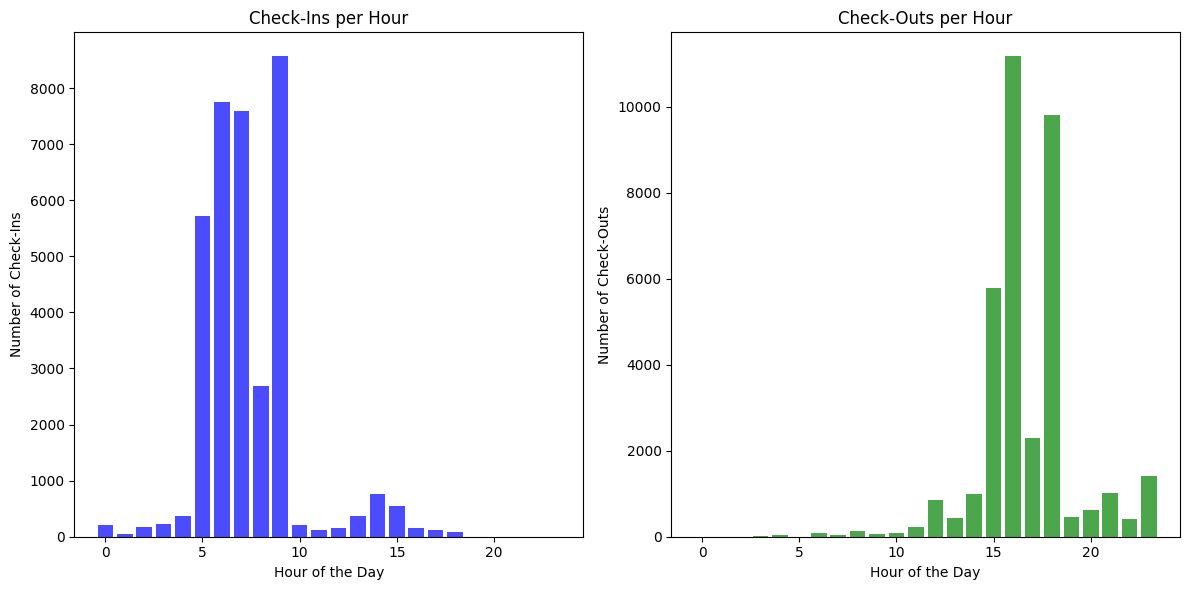

In [26]:

# Load dataset
get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/processed/3272_aldella'))
csv_file = '3272_aldella_transformation_data.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

DSet = pd.read_csv(absolute_path)

# Convert 'CheckInTime' and 'CheckOutTime' from HH:MM format to minutes since midnight
DSet['CheckInHour'] = pd.to_datetime(DSet['CheckInTime']).dt.hour 
DSet['CheckOutHour'] = pd.to_datetime(DSet['CheckOutTime']).dt.hour 


# Count check-ins per hour
check_in_counts = DSet['CheckInHour'].value_counts().sort_index()

# Count check-outs per hour
check_out_counts = DSet['CheckOutHour'].value_counts().sort_index()

# Create a DataFrame for plotting
hours = range(24)
check_in_counts = check_in_counts.reindex(hours, fill_value=0)
check_out_counts = check_out_counts.reindex(hours, fill_value=0)

# Plot results
plt.figure(figsize=(12, 6))

# Plot Check-In counts
plt.subplot(1, 2, 1)
plt.bar(check_in_counts.index, check_in_counts.values, color='blue', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Ins')
plt.title('Check-Ins per Hour')

# Plot Check-Out counts
plt.subplot(1, 2, 2)
plt.bar(check_out_counts.index, check_out_counts.values, color='green', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Outs')
plt.title('Check-Outs per Hour')

plt.tight_layout()
plt.show()


In [27]:
# Convert CheckInTime to minutes since midnight
def time_to_minutes(t):
    h, m, s = map(int, t.split(':'))
    return h * 60 + m + s / 60  # Convert seconds to minutes

DSet['CheckInMinutes'] = DSet['CheckInTime'].apply(time_to_minutes)
DSet['CheckOutMinutes'] = DSet['CheckOutTime'].apply(time_to_minutes)

# Feature engineering: Create features for clustering
features = DSet[['CheckInMinutes']] #, 'CheckOutMinutes']].values
features = StandardScaler().fit_transform(features)  # Normalize features

# K-Means Clustering
def optimal_k_means(features):
    silhouette_scores = []
    k_range = range(2, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(features)
        labels = kmeans.labels_
        silhouette_avg = silhouette_score(features, labels)
        silhouette_scores.append(silhouette_avg)
    optimal_k = k_range[np.argmax(silhouette_scores)]
    return optimal_k



10
0.7246879017610884


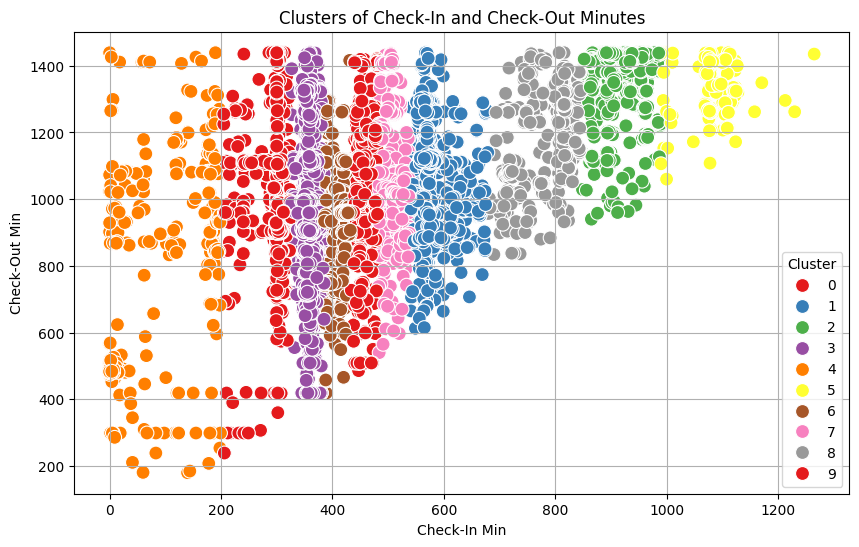

In [28]:
optimal_k = optimal_k_means(features)

print(optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
DSet['cluster'] = kmeans.fit_predict(features)

silhouette_avg = silhouette_score(features, DSet['cluster'])
print(silhouette_avg)
# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CheckInMinutes', y='CheckOutMinutes', hue=df['cluster'], data=df, palette='Set1', s=100)
plt.title('Clusters of Check-In and Check-Out Minutes')
plt.xlabel('Check-In Min')
plt.ylabel('Check-Out Min')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


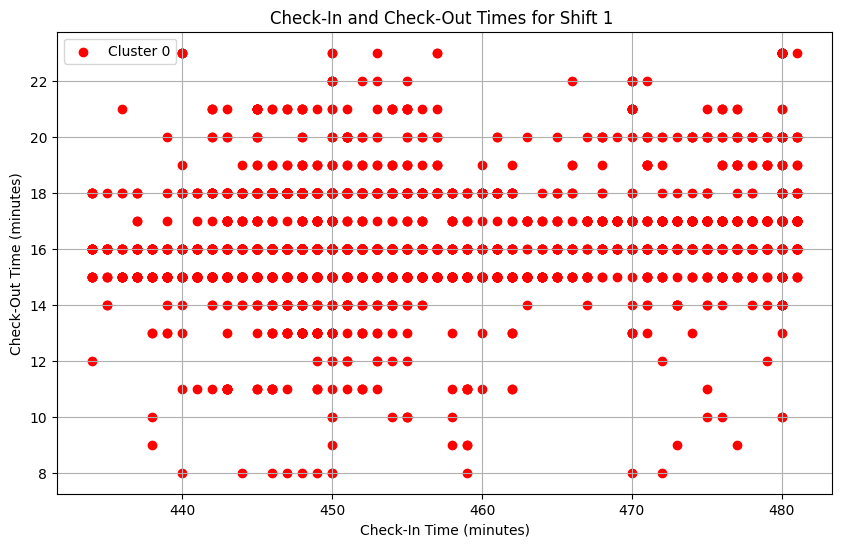

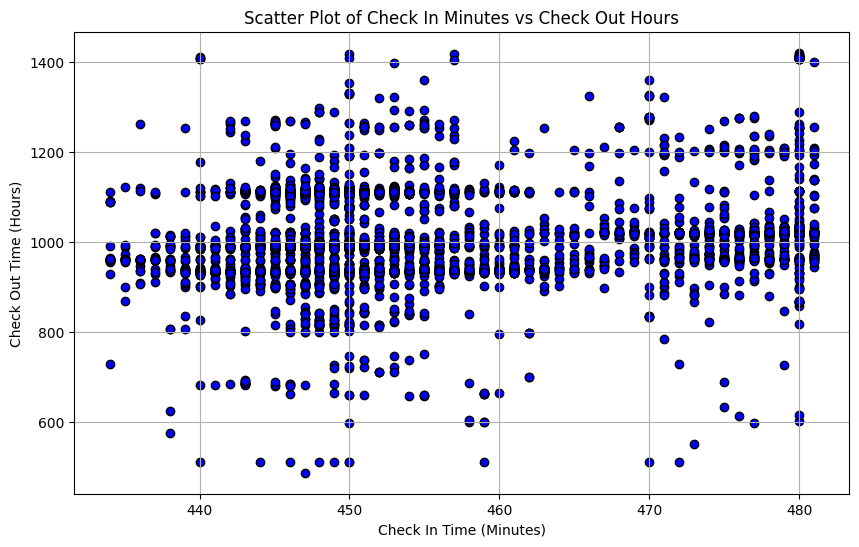

<Figure size 1500x800 with 0 Axes>

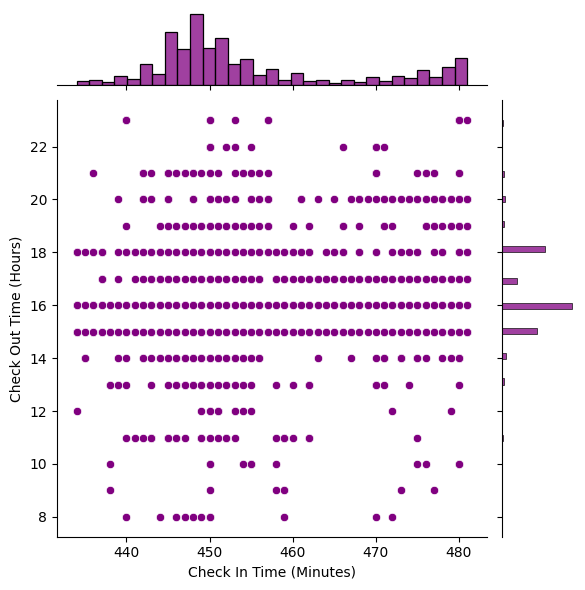

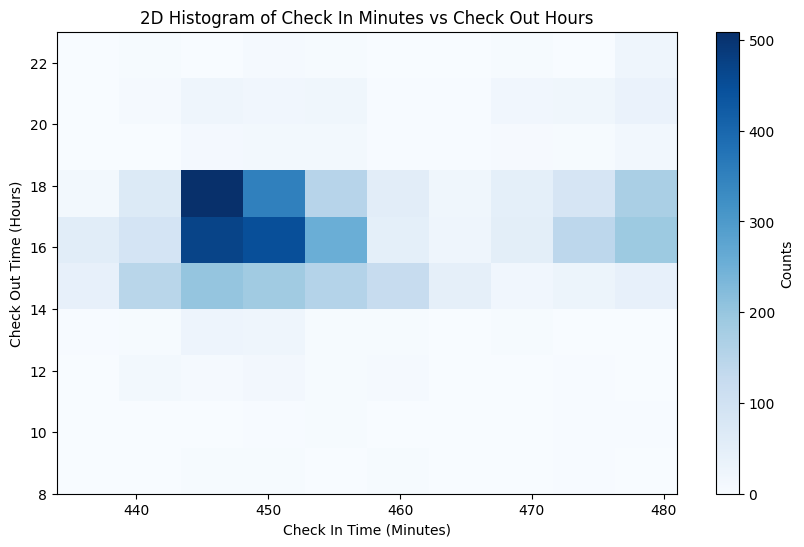

In [29]:
# Filter the DataFrame for Cluster 0
cluster_df = DSet[DSet['cluster'] == 0]
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInMinutes'], cluster_df['CheckOutHour'], color='red', label='Cluster 0')
plt.title('Check-In and Check-Out Times for Shift 1 ')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

# 1. Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInMinutes'], cluster_df['CheckOutMinutes'], color='blue', edgecolor='black')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.title('Scatter Plot of Check In Minutes vs Check Out Hours')
plt.grid(True)
plt.show()


# 4. Joint Plot (Scatter + Distribution)
plt.figure(figsize=(15, 8))
sns.jointplot(x= cluster_df['CheckInMinutes'], y= cluster_df['CheckOutHour'], kind='scatter', color='purple')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.show()


# 6. 2D Histogram
plt.figure(figsize=(10, 6))
plt.hist2d(cluster_df['CheckInMinutes'], cluster_df['CheckOutHour'], bins=10, cmap='Blues')
plt.colorbar(label='Counts')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.title('2D Histogram of Check In Minutes vs Check Out Hours')
plt.show()

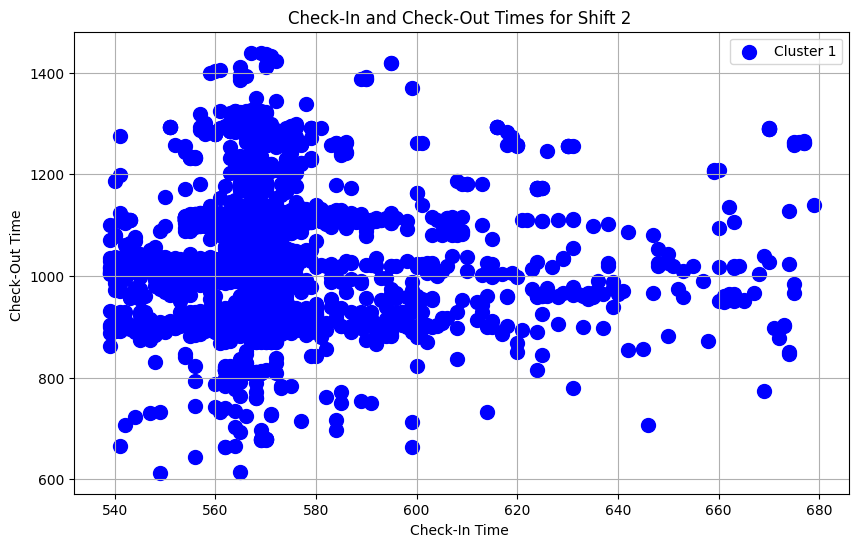

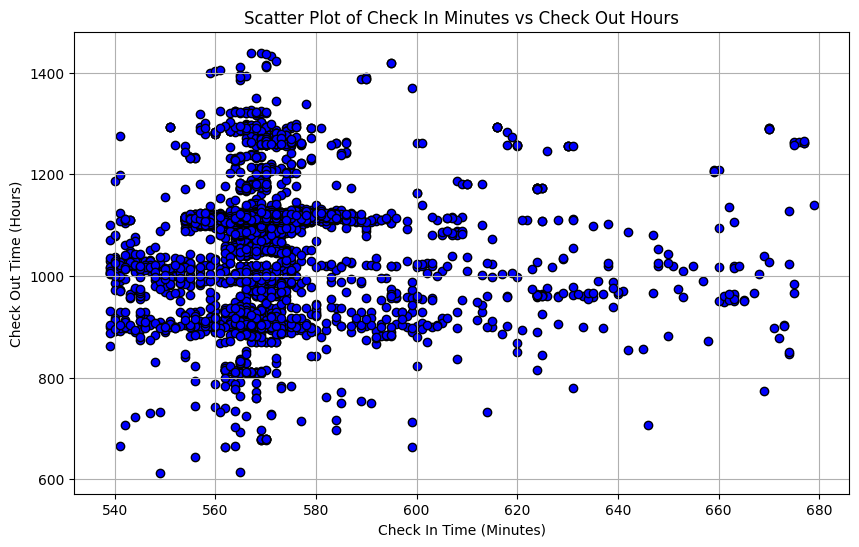

<Figure size 1500x800 with 0 Axes>

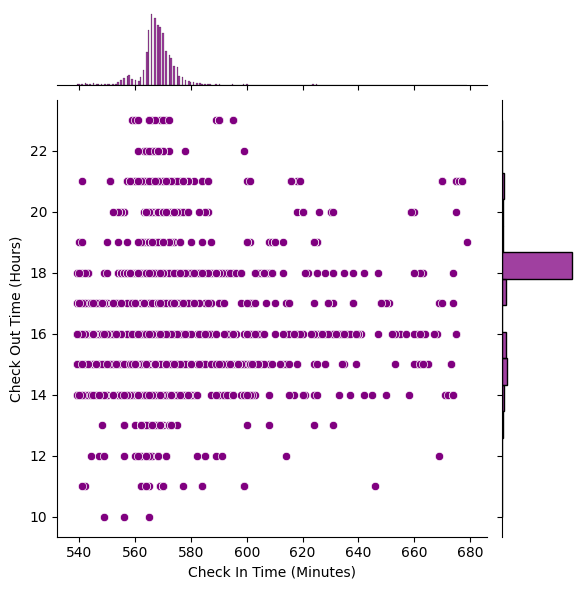

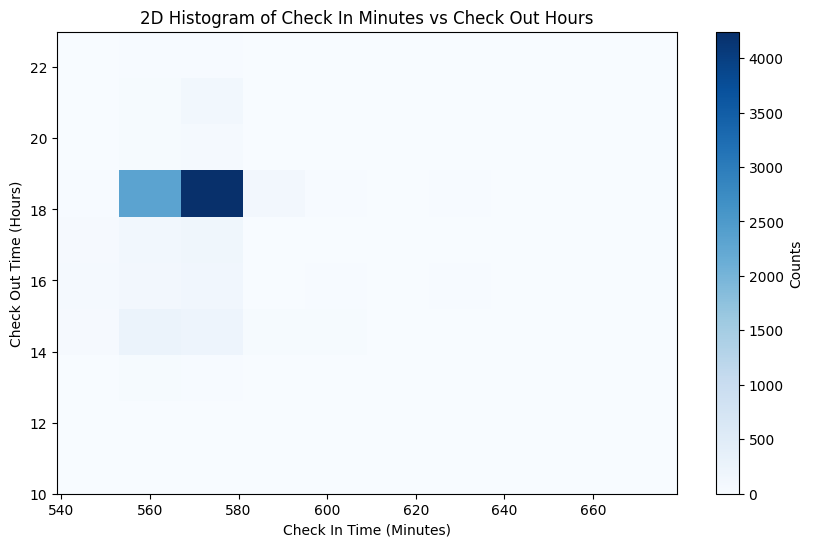

In [30]:
cluster_df = DSet[DSet['cluster'] == 1]
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInMinutes'], cluster_df['CheckOutMinutes'], color='blue', label='Cluster 1', s=100)
plt.title('Check-In and Check-Out Times for Shift 2 ')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()



# 1. Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInMinutes'], cluster_df['CheckOutMinutes'], color='blue', edgecolor='black')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.title('Scatter Plot of Check In Minutes vs Check Out Hours')
plt.grid(True)
plt.show()


# 4. Joint Plot (Scatter + Distribution)
plt.figure(figsize=(15, 8))
sns.jointplot(x= cluster_df['CheckInMinutes'], y= cluster_df['CheckOutHour'], kind='scatter', color='purple')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.show()


# 6. 2D Histogram
plt.figure(figsize=(10, 6))
plt.hist2d(cluster_df['CheckInMinutes'], cluster_df['CheckOutHour'], bins=10, cmap='Blues')
plt.colorbar(label='Counts')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.title('2D Histogram of Check In Minutes vs Check Out Hours')
plt.show()

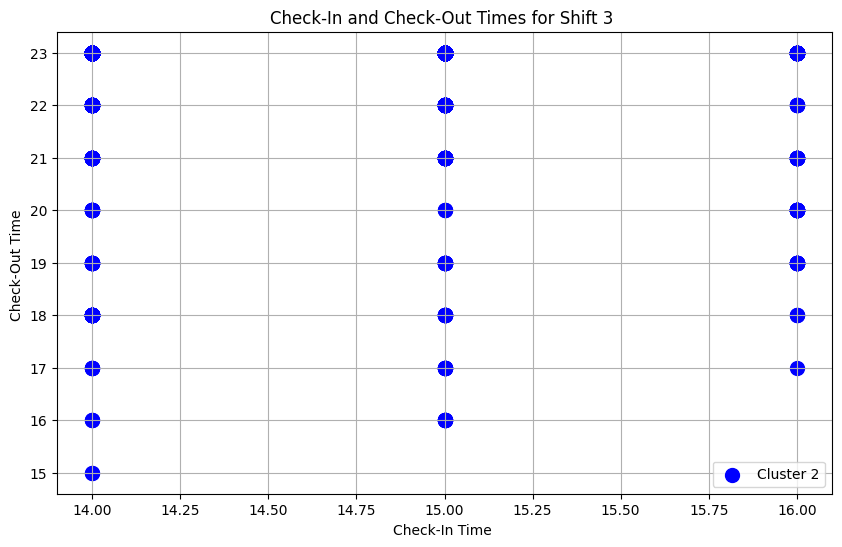

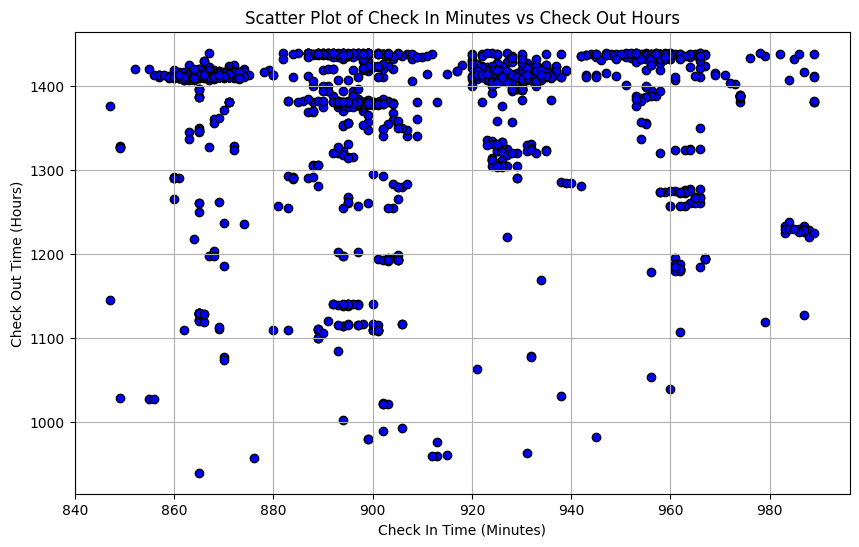

<Figure size 1500x800 with 0 Axes>

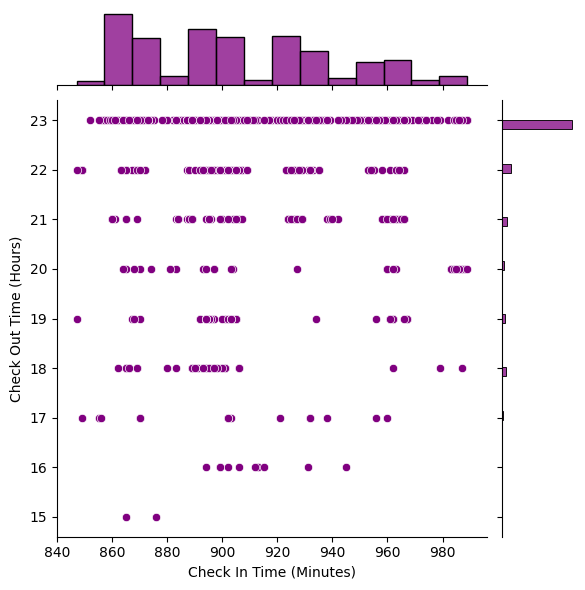

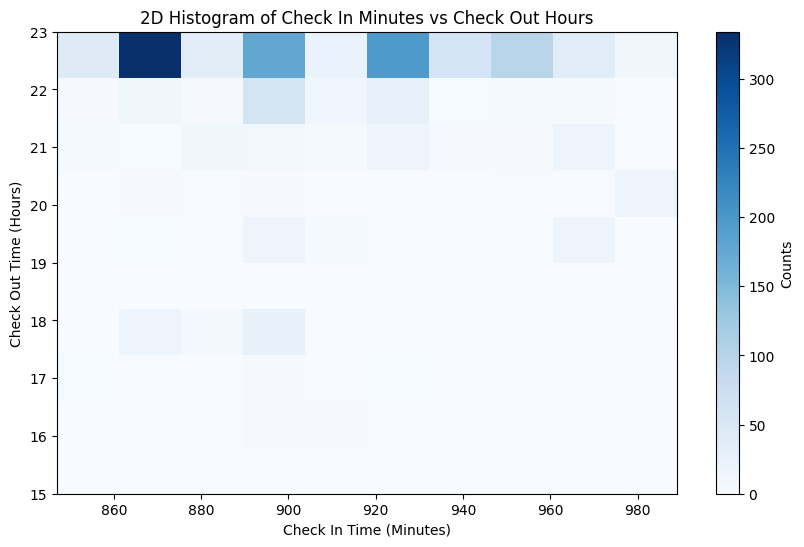

In [31]:
cluster_df = df[df['cluster'] == 2]
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='blue', label='Cluster 2', s=100)
plt.title('Check-In and Check-Out Times for Shift 3 ')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()


# 1. Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInMinutes'], cluster_df['CheckOutMinutes'], color='blue', edgecolor='black')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.title('Scatter Plot of Check In Minutes vs Check Out Hours')
plt.grid(True)
plt.show()


# 4. Joint Plot (Scatter + Distribution)
plt.figure(figsize=(15, 8))
sns.jointplot(x= cluster_df['CheckInMinutes'], y= cluster_df['CheckOutHour'], kind='scatter', color='purple')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.show()


# 6. 2D Histogram
plt.figure(figsize=(10, 6))
plt.hist2d(cluster_df['CheckInMinutes'], cluster_df['CheckOutHour'], bins=10, cmap='Blues')
plt.colorbar(label='Counts')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.title('2D Histogram of Check In Minutes vs Check Out Hours')
plt.show()

In [32]:
employee_count_per_cluster = df.groupby('cluster')['EmployeeId'].nunique().reset_index()

# Rename columns for clarity
employee_count_per_cluster.columns = ['cluster', 'NumberOfEmployees']

# Print the result
print(employee_count_per_cluster)

   cluster  NumberOfEmployees
0        0                128
1        1                119
2        2                 84
3        3                101
4        4                 55
5        5                 54
6        6                113
7        7                 79
8        8                 81
9        9                104


In [33]:

# Calculate start and end hours for each cluster
# Calculate statistics for each cluster
cluster_summary = df.groupby('cluster').agg({
    'CheckInHour': ['mean', 'min', 'max'],
    'CheckOutHour': ['mean', 'min', 'max']
}).reset_index()

# Flatten MultiIndex columns
cluster_summary.columns = ['Cluster', 'CheckInHour_Mean', 'CheckInHour_Min', 'CheckInHour_Max',
                           'CheckOutHour_Mean', 'CheckOutHour_Min', 'CheckOutHour_Max']

# Print the summary
print(cluster_summary)


   Cluster  CheckInHour_Mean  CheckInHour_Min  CheckInHour_Max  \
0        0          7.053388                7                8   
1        1          9.032371                8               11   
2        2         14.577033               14               16   
3        3          5.402973                5                6   
4        4          1.463087                0                3   
5        5         17.271255               16               21   
6        6          6.404777                6                7   
7        7          8.000000                8                8   
8        8         12.606583               11               14   
9        9          4.679114                3                5   

   CheckOutHour_Mean  CheckOutHour_Min  CheckOutHour_Max  
0          16.423027                 8                23  
1          17.666214                10                23  
2          22.248217                15                23  
3          15.628195                 

Attendance Counts for Each 30-Minute Interval:
          TimeInterval  Count  MinutesSinceMidnight
0  2024-10-05 00:00:00    187                     0
1  2024-10-05 00:30:00     26                    30
2  2024-10-05 01:00:00     29                    60
3  2024-10-05 01:30:00     22                    90
4  2024-10-05 02:00:00     35                   120
5  2024-10-05 02:30:00    140                   150
6  2024-10-05 03:00:00    175                   180
7  2024-10-05 03:30:00     50                   210
8  2024-10-05 04:00:00    144                   240
9  2024-10-05 04:30:00    227                   270
10 2024-10-05 05:00:00   1173                   300
11 2024-10-05 05:30:00   4546                   330
12 2024-10-05 06:00:00   3279                   360
13 2024-10-05 06:30:00   4471                   390
14 2024-10-05 07:00:00   5184                   420
15 2024-10-05 07:30:00   2400                   450
16 2024-10-05 08:00:00   1604                   480
17 2024-10-05 08:

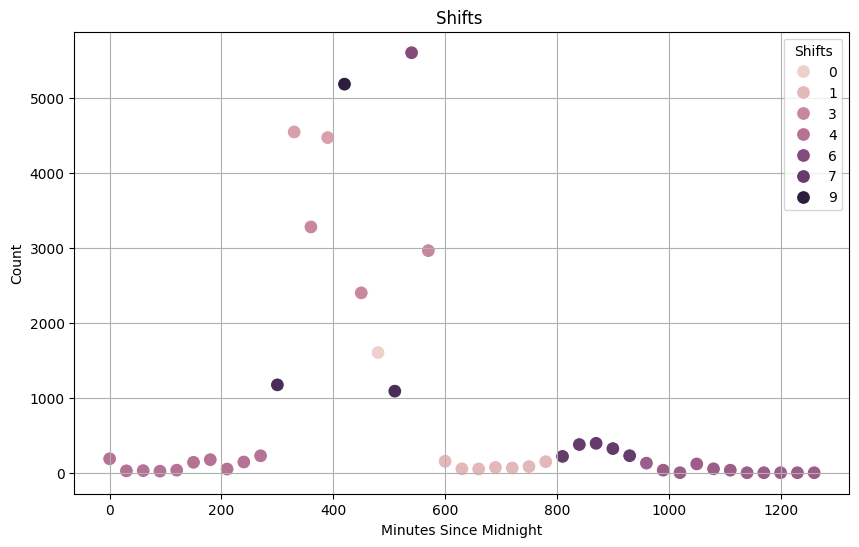

In [34]:
# Convert CheckInTime to datetime format and round to the nearest 30 minutes
DSet['CheckInTime'] = pd.to_datetime(DSet['CheckInTime'], format='%H:%M:%S').dt.time

def round_to_nearest_30_minutes(time):
    # Convert time to minutes, round to nearest 30, then convert back to time
    minute = (time.minute // 30) * 30
    return time.replace(minute=minute, second=0, microsecond=0)

# Apply rounding function
DSet['RoundedCheckInTime'] = DSet['CheckInTime'].apply(lambda x: round_to_nearest_30_minutes(pd.Timestamp.combine(pd.Timestamp.today(), x)))

# Count occurrences for each 30-minute interval
attendance_counts = DSet['RoundedCheckInTime'].value_counts().sort_index()

# Convert to DataFrame for clustering
attendance_df = attendance_counts.reset_index()
attendance_df.columns = ['TimeInterval', 'Count']

print("Attendance Counts for Each 30-Minute Interval:")
#print(attendance_df)

# Convert TimeInterval to numerical feature (e.g., minutes since midnight)
def time_to_minutes(time_obj):
    # Ensure the time_obj is in proper format (HH:MM)
    if isinstance(time_obj, pd.Timestamp):
        hours, minutes = time_obj.hour, time_obj.minute
    else:
        hours, minutes = map(int, str(time_obj).split(':'))
    return hours * 60 + minutes

attendance_df['MinutesSinceMidnight'] = attendance_df['TimeInterval'].apply(time_to_minutes)

print(attendance_df)


# Features for clustering
features = attendance_df[['MinutesSinceMidnight', 'Count']]

# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
# K-Means Clustering
def optimal_k_means(features):
    silhouette_scores = []
    k_range = range(2, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(features)
        labels = kmeans.labels_
        silhouette_avg = silhouette_score(features, labels)
        silhouette_scores.append(silhouette_avg)
    optimal_k = k_range[np.argmax(silhouette_scores)]
    return optimal_k

#optimal_k = optimal_k_means(scaled_features)
optimal_k = 10
print(optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
attendance_df['Shifts'] = kmeans.fit_predict(features)

silhouette_avg = silhouette_score(features, attendance_df['Shifts'])
print(silhouette_avg)
# Plot the clusters

plt.figure(figsize=(10, 6))

#for i in range(optimal_k):
#    cluster_data = attendance_df[attendance_df['Shifts'] == i]
#    plt.scatter(cluster_data['MinutesSinceMidnight'], cluster_data['Count'], label=f'Shifts {i}')
#    plt.plot(cluster_data['MinutesSinceMidnight'], cluster_data['Count'], linestyle='-', marker='o')


sns.scatterplot(x='MinutesSinceMidnight', y='Count', hue=attendance_df['Shifts'], data=attendance_df, s=100)
plt.title('Shifts ')
plt.xlabel('Minutes Since Midnight')
plt.ylabel('Count')
plt.legend(title='Shifts')
plt.grid(True)
plt.show()



Attendance Counts for Each 30-Minute Interval:
          TimeInterval  Count  HoursSinceMidnight
0  2024-10-05 00:00:00    213                   0
1  2024-10-05 01:00:00     51                   1
2  2024-10-05 02:00:00    175                   2
3  2024-10-05 03:00:00    225                   3
4  2024-10-05 04:00:00    371                   4
5  2024-10-05 05:00:00   5719                   5
6  2024-10-05 06:00:00   7750                   6
7  2024-10-05 07:00:00   7584                   7
8  2024-10-05 08:00:00   2693                   8
9  2024-10-05 09:00:00   8566                   9
10 2024-10-05 10:00:00    207                  10
11 2024-10-05 11:00:00    123                  11
12 2024-10-05 12:00:00    147                  12
13 2024-10-05 13:00:00    367                  13
14 2024-10-05 14:00:00    770                  14
15 2024-10-05 15:00:00    551                  15
16 2024-10-05 16:00:00    164                  16
17 2024-10-05 17:00:00    119                  17
18 

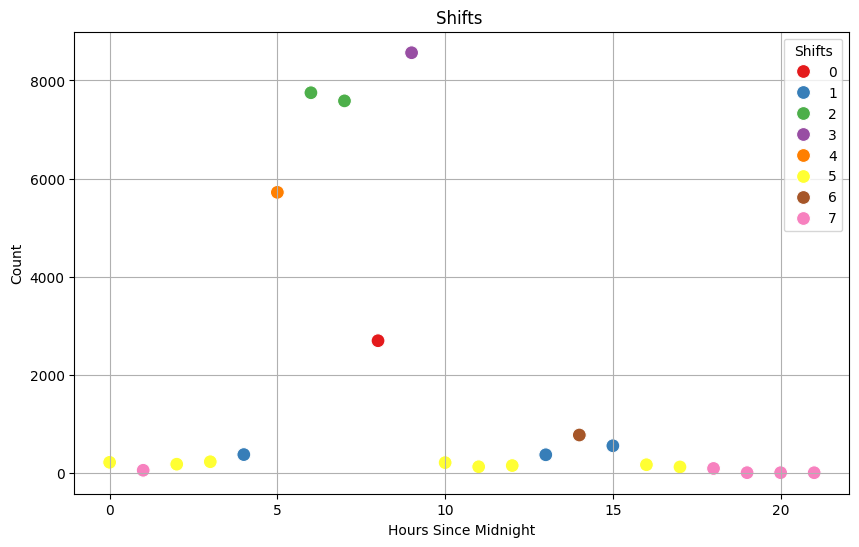

In [35]:
# Convert CheckInTime to datetime format and round to the nearest 30 minutes
DSet['CheckInTime'] = pd.to_datetime(DSet['CheckInTime'], format='%H:%M:%S').dt.time

# Function to round times to the nearest hour
def round_to_nearest_hour(time):
    hour = time.hour
    return time.replace(minute=0, second=0, microsecond=0)

# Apply rounding function
DSet['RoundedCheckInTime_H'] = DSet['CheckInTime'].apply(lambda x: round_to_nearest_hour(pd.Timestamp.combine(pd.Timestamp.today(), x)))

# Count occurrences for each 30-minute interval
attendance_counts_H = DSet['RoundedCheckInTime_H'].value_counts().sort_index()

# Convert to DataFrame for clustering
attendance_df_H = attendance_counts_H.reset_index()
attendance_df_H.columns = ['TimeInterval', 'Count']

print("Attendance Counts for Each 30-Minute Interval:")
#print(attendance_df)
# Convert TimeInterval to numerical feature (e.g., hours since midnight)
def time_to_hours(time_obj):
    return time_obj.hour

attendance_df_H['HoursSinceMidnight'] = attendance_df_H['TimeInterval'].apply(time_to_hours)

print(attendance_df_H)


# Features for clustering
features = attendance_df_H[['HoursSinceMidnight', 'Count']]

# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
# K-Means Clustering
def optimal_k_means(features):
    silhouette_scores = []
    k_range = range(2, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(features)
        labels = kmeans.labels_
        silhouette_avg = silhouette_score(features, labels)
        silhouette_scores.append(silhouette_avg)
    optimal_k = k_range[np.argmax(silhouette_scores)]
    return optimal_k

#optimal_k = optimal_k_means(scaled_features)
optimal_k = 8
print(optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
attendance_df_H['Shifts'] = kmeans.fit_predict(features)

silhouette_avg = silhouette_score(features, attendance_df_H['Shifts'])
print(silhouette_avg)
# Plot 

plt.figure(figsize=(10, 6))
sns.scatterplot(x='HoursSinceMidnight', y='Count', hue=attendance_df_H['Shifts'], data=attendance_df_H, palette='Set1', s=100)
plt.title('Shifts ')
plt.xlabel('Hours Since Midnight')
plt.ylabel('Count')
plt.legend(title='Shifts')
plt.grid(True)
plt.show()




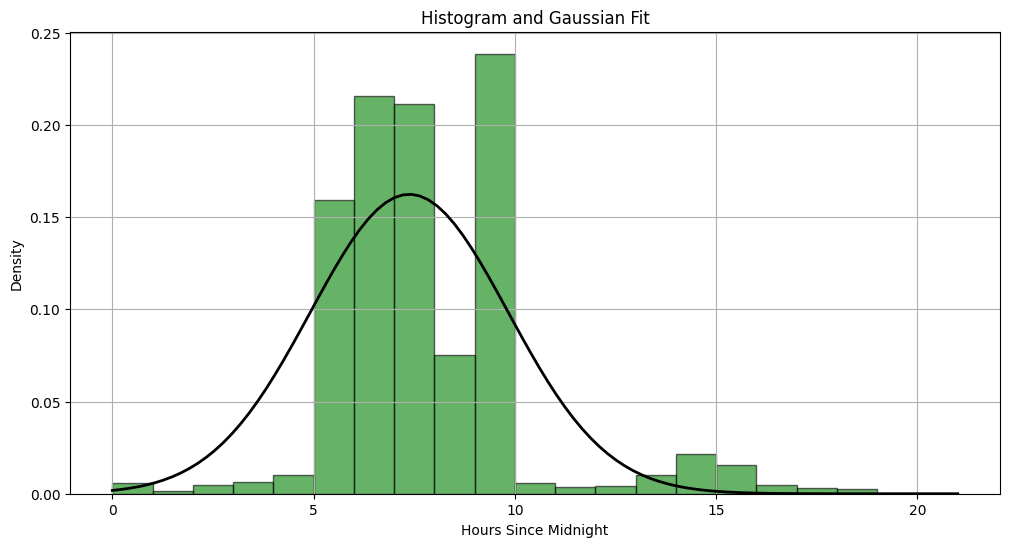

In [36]:

expanded_data = []
for _, row in attendance_df_H.iterrows():
    expanded_data.extend([row['HoursSinceMidnight']] * row['Count'])

expanded_data = np.array(expanded_data)

# Fit Gaussian distribution
mu, std = norm.fit(expanded_data)

# Create a range of values for plotting the Gaussian distribution
xmin, xmax = expanded_data.min(), expanded_data.max()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot histogram and Gaussian fit
plt.figure(figsize=(12, 6))

# Plot histogram
plt.hist(expanded_data, bins=range(int(xmin), int(xmax) + 1), density=True, alpha=0.6, color='g', edgecolor='black')

#Plot Gaussian distribution
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel('Hours Since Midnight')
plt.ylabel('Density')
plt.title('Histogram and Gaussian Fit')
plt.grid(True)
plt.show()

